### Imports & display options: Load pandas/numpy/plotting, set wide display. Bring in StandardScaler, KMeans, silhouette, and TSNE. Define RS and silence warnings.

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.patches import Rectangle

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
# Define a common seed value to be used throughout
RS=0

In [3]:
# Specify file path
file_path = r"Oils.csv"
# Read the CSV file
data = pd.read_csv(file_path)
df_oils = data.copy()
df_oils = df_oils.drop(columns=['Unnamed: 0'])
df_oils

Oil_Type Oil  500.8563  501.8205  502.7847   503.749  504.7132  505.6774  \
0        SO 0  SO -0.458101 -1.495276 -1.862568 -1.831711 -1.535953 -0.993022   
1        SO 0  SO  0.068097 -0.399315 -0.678853 -0.814568 -0.855950 -0.791816   
2        SO 0  SO  0.167223 -1.133351 -1.652558 -1.617278 -1.226656 -0.573671   
3        SO 0  SO -0.271799 -0.583166 -0.724528 -0.798817 -0.848749 -0.863939   
4        SO 0  SO -0.194513 -0.940731 -1.160886 -1.062074 -0.771085 -0.351588   
..        ...  ..       ...       ...       ...       ...       ...       ...   
995  VO 9      VO -0.034947 -0.180810 -0.391828 -0.642584 -0.917746 -1.148100   
996  VO 9      VO -0.639607 -0.416230 -0.093788  0.188944  0.435340  0.617132   
997  VO 9      VO  0.239122 -0.131614 -0.470480 -0.741282 -0.963708 -1.093654   
998  VO 9      VO  0.441411  0.046997 -0.093115 -0.006286  0.218919  0.493749   
999  VO 9      VO  0.509218  0.538932  0.333033  0.056121 -0.254349 -0.546759   

     506.6417  507.6059  508.5701  509.5344  510.4986  511.4628  512.4271  \
0   -0.391103  0.233167  0.736664  0.991370  0.956672  0.700951  0.449719   
1   -0.674305 -0.513736 -0.342651 -0.190976 -0.068750  0.035006  0.158178   
2    0.003154  0.458940  0.678271  0.660841  0.476559  0.149576 -0.206054   
3   -0.920526 -1.022233 -1.144028 -1.235504 -1.258568 -1.221066 -1.130485   
4   -0.068750  0.085753  0.086389 -0.049578 -0.287679 -0.597473 -0.835858   
..        ...       ...       ...       ...       ...       ...       ...   
995 -1.260009 -1.219511 -1.034384 -0.812137 -0.701306 -0.716923 -0.737459   
996  0.727431  0.707909  0.499717  0.164448 -0.128971 -0.298578 -0.400542   
997 -1.115323 -1.014951 -0.814825 -0.585053 -0.380516 -0.174933  0.109224   
998  0.603295  0.558233  0.378946  0.127683 -0.135317 -0.394342 -0.581880   
999 -0.669432 -0.642831 -0.518620 -0.336601 -0.115073  0.132493  0.320762   

     513.3913  514.3555  515.3198   516.284  517.2482  518.2125  519.1767  \
0    0.244738  0.068509 -0.056937 -0.095208 -0.054344  0.033550  0.174181   
1    0.257007  0.293209  0.267117  0.205402  0.124151  0.025600 -0.086357   
2   -0.458698 -0.556581 -0.595982 -0.690896 -0.847410 -0.968523 -0.958749   
3   -0.978780 -0.783513 -0.585774 -0.433292 -0.321451 -0.220201 -0.116622   
4   -0.928414 -0.923756 -0.844943 -0.687609 -0.441944 -0.168795  0.007971   
..        ...       ...       ...       ...       ...       ...       ...   
995 -0.808927 -0.985596 -1.179307 -1.289544 -1.287319 -1.231989 -1.200206   
996 -0.436871 -0.377856 -0.263907 -0.175587 -0.178344 -0.273663 -0.380336   
997  0.353533  0.460641  0.436405  0.332651  0.177417 -0.016361 -0.203921   
998 -0.623249 -0.547883 -0.420067 -0.285472 -0.139599  0.008037  0.097770   
999  0.345377  0.206514 -0.006959 -0.213094 -0.400342 -0.586358 -0.764731   

     520.1409  521.1052  522.0694  523.0336  523.9979  524.9621  525.9263  \
0    0.395118  0.683926  0.992200  1.180071  1.182973  1.020644  0.753777   
1   -0.177832 -0.173041 -0.049842  0.113304  0.246327  0.328197  0.370578   
2   -0.801991 -0.545173 -0.208500  0.195862  0.591162  0.832790  0.819308   
3   -0.032726 -0.050288 -0.198163 -0.454155 -0.789566 -1.171456 -1.498739   
4    0.023840 -0.065639 -0.214114 -0.368551 -0.475957 -0.435494 -0.292340   
..        ...       ...       ...       ...       ...       ...       ...   
995 -1.200782 -1.217742 -1.285179 -1.427141 -1.593423 -1.632586 -1.473163   
996 -0.431772 -0.491162 -0.607294 -0.734749 -0.815847 -0.870245 -0.883747   
997 -0.313380 -0.358470 -0.412703 -0.569988 -0.809364 -1.042693 -1.204265   
998  0.071974 -0.108498 -0.442006 -0.806642 -1.077495 -1.157047 -1.080248   
999 -0.895696 -0.920941 -0.844384 -0.729825 -0.620531 -0.510037 -0.418282   

     526.8906  527.8548   528.819  529.7833  530.7475  531.7117   532.676  \
0    0.460243  0.180036 -0.069201 -0.278928 -0.437419 -0.525460 -0.566531   
1    0.384977  0.338642  0.190685 -0.041291 -0.257086 -0.376210 -0.392517   
2    0.565549  0.199350 -0

In [4]:
# Spectral data starts from column 2
spectra = df_oils.iloc[:, 2:]

# Most negative value in the entire spectral dataset
min_value = spectra.min().min()

# Find row and column containing the minimum value
row_idx, col_idx = (spectra == min_value).stack().idxmax()

print("Most negative value:", min_value)
print("Most negative value:", min_value)
print("Row index:", row_idx)
print("Wavenumber:", col_idx)

Most negative value: -7.583057172006416
Most negative value: -7.583057172006416
Row index: 622
Wavenumber: 1337.811


In [5]:
# shift = abs(min_value)

# df_oils = df_oils.copy()
# df_oils.iloc[:, 2:] = df_oils.iloc[:, 2:] + shift

# print("New minimum:", df_oils.iloc[:, 2:].min().min())

In [6]:
#Define features (X) and Target (y)
X = df_oils.drop(columns=['Oil_Type','Oil'])
y= df_oils['Oil']
X = X.astype(float)
# X,y

### Build X (features) and keep y (labels) for later validation after clustering algo. 

In [7]:
df = X

### Scaling

### Scaling is compulsory for clustering

In [8]:
# scaling the data before clustering
scaler = MinMaxScaler()

subset = df.copy()
subset_scaled = scaler.fit_transform(subset)

In [9]:
# creating a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

### t‑SNE to 2D (for visualization only): Reduce to 2D with t‑SNE (random_state=RS), create `Features 1 and 2` DataFrame, quick preview.

In [10]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state= RS, perplexity = 30.0)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [11]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,28.459091,-2.348838
1,28.614382,-3.750810
2,32.653709,-6.098471
3,33.165524,-6.217761
4,32.982391,-7.085877


In [12]:
# Fix color palette 
palette = {
    "SO": "tab:blue",
    "PO": "tab:orange",
    "GNO": "tab:green",
    "SOYO": "tab:red",
    "VO": "tab:purple"
}

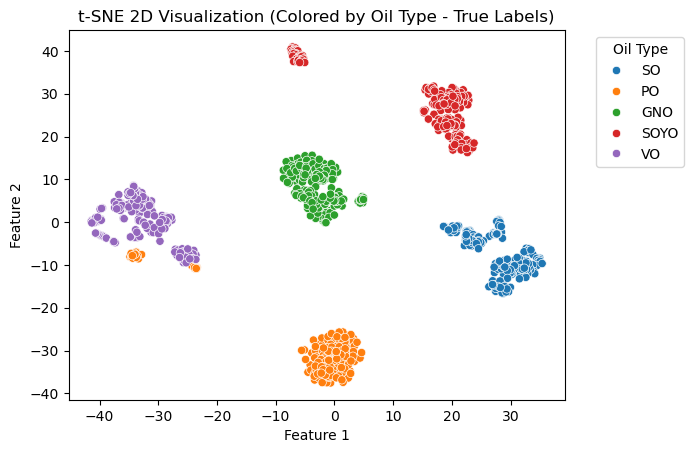

In [13]:
# #Add true labels 
tsne_2d_data = tsne_2d_data.copy()
tsne_2d_data["Oil_Type"] = y.reset_index(drop = True)

#Plot with colors = oil type
sns.scatterplot(
    data = tsne_2d_data,
    x = "Feature 1",
    y = "Feature 2",
    hue = "Oil_Type",
    palette=palette
    #palette = "tab10"
)
plt.legend(title = "Oil Type", loc="upper left",bbox_to_anchor = (1.05,1))
plt.title("t-SNE 2D Visualization (Colored by Oil Type - True Labels)")
plt.savefig(r"Images\K-Means Clusters\MinMaxScaler_tsne_plot_default_oils.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

In [14]:
# Let us check the default perplexity. Perplexity is the number of neighbors influencing each point
print(TSNE().get_params()["perplexity"])

30.0


### We see VO and PO oils similar. Let us check at different perplexities

### t‑SNE sensitivity to perplexity: Multiple 2D views at different perplexities to check stability of local neighborhoods.

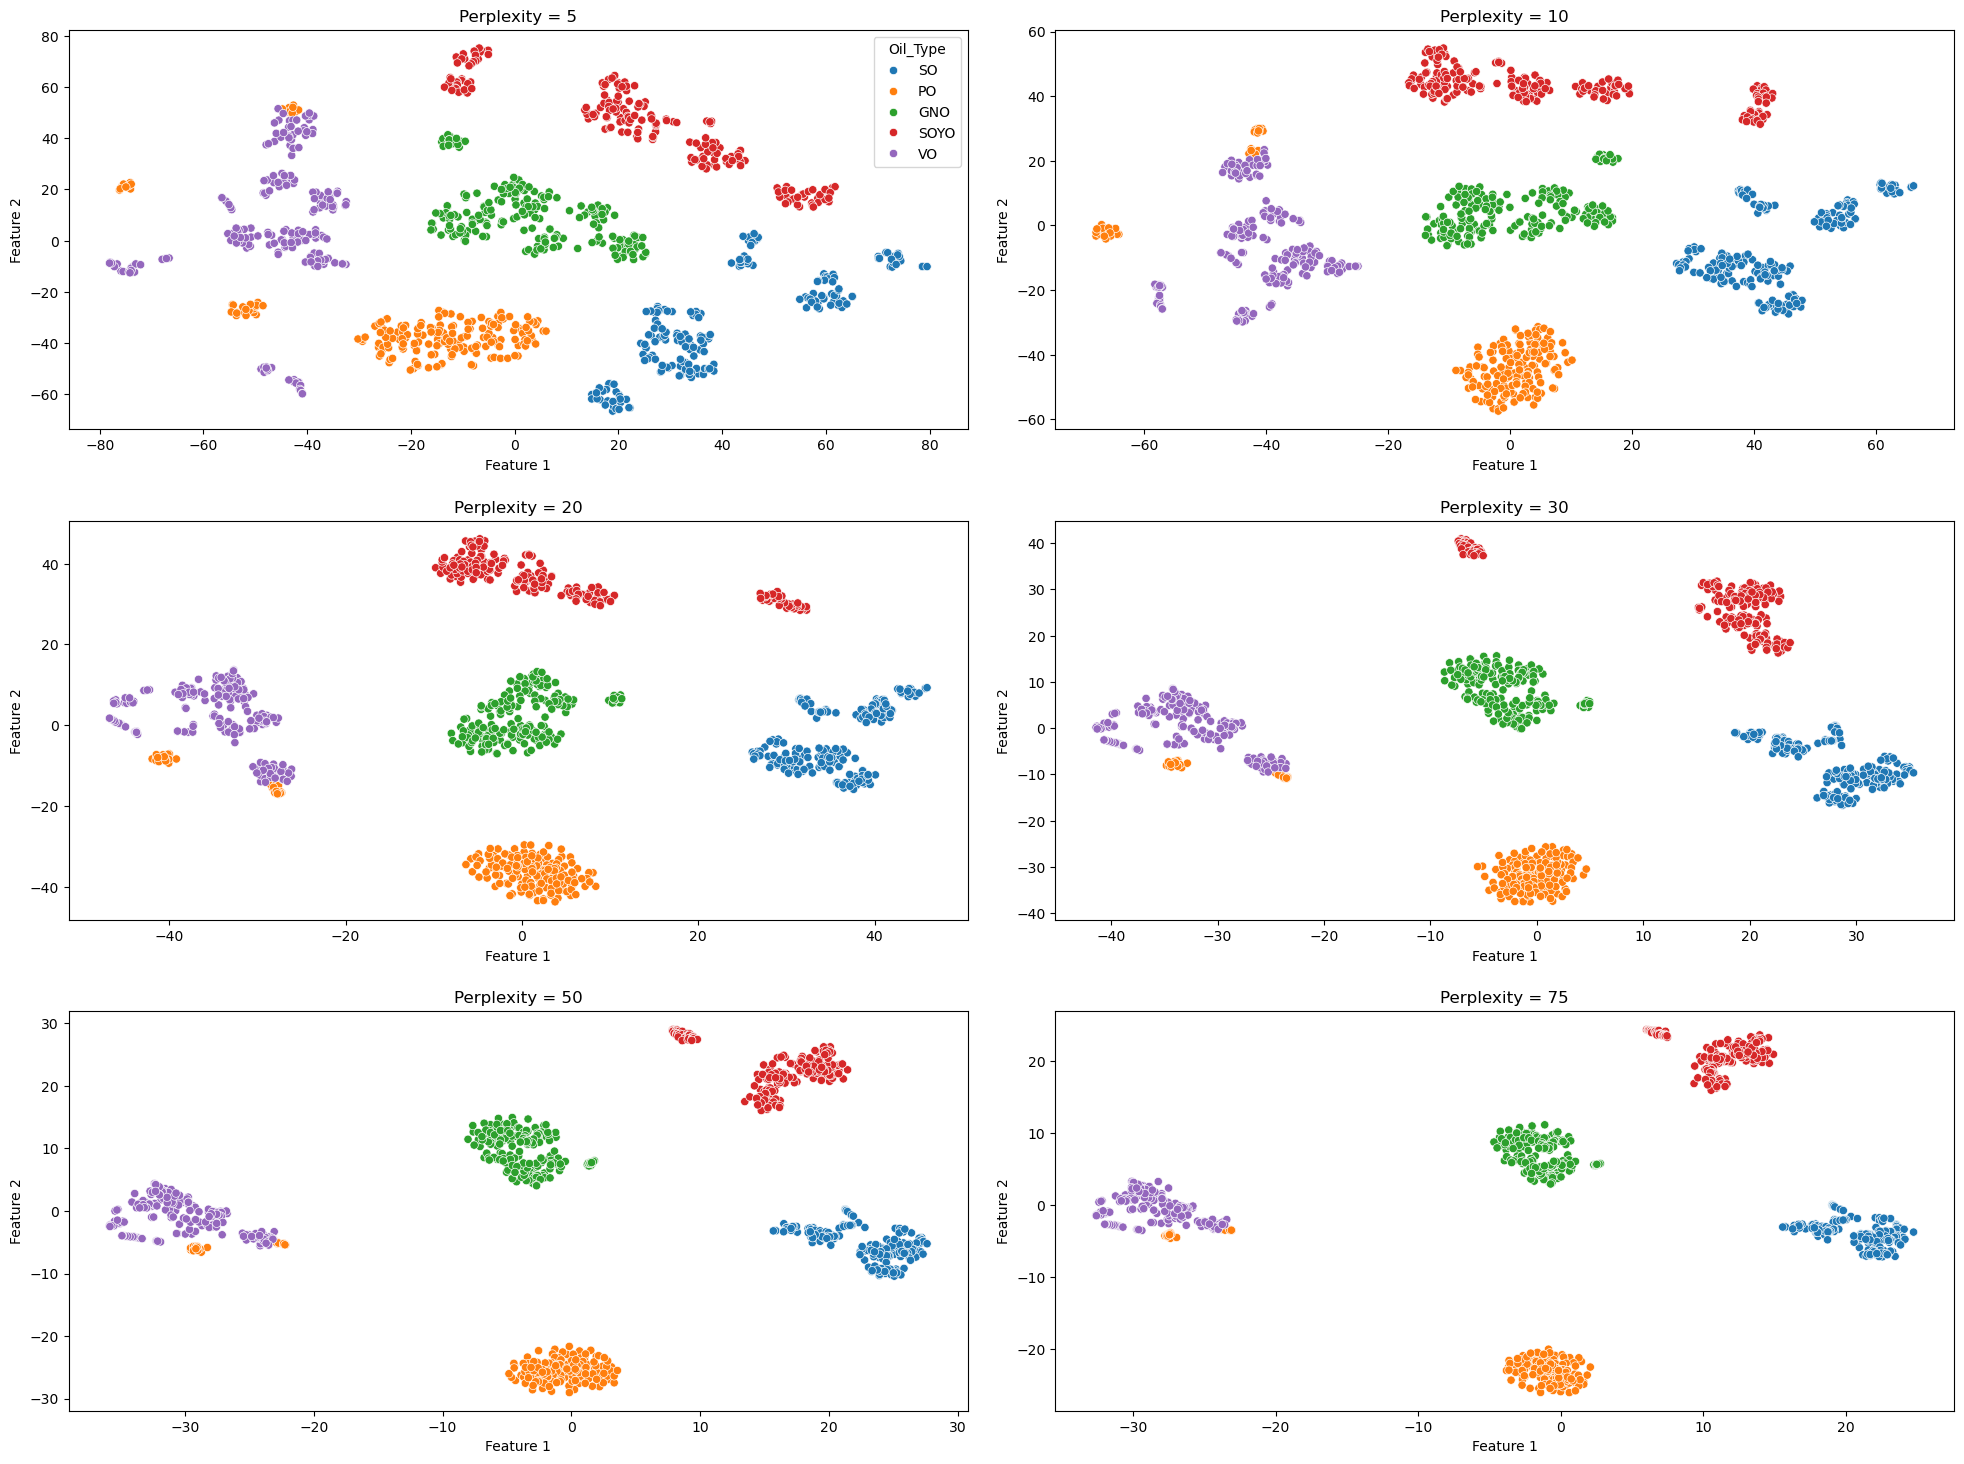

In [15]:
hue_order = ["SO", "PO", "GNO", "SOYO", "VO"]

# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 30, 50, 75]

plt.figure(figsize=(20, 15))

for i in range(len(perplexities)):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexities[i],
        n_jobs=-2,
        random_state=RS
    )

    X_red = tsne.fit_transform(subset_scaled_df)

    red_data_df = pd.DataFrame(
        data=X_red,
        columns=["Feature 1", "Feature 2"]
    )

    red_data_df["Oil_Type"] = y.reset_index(drop=True)

    plt.subplot(3, 2, i + 1)

    sns.scatterplot(
        data=red_data_df,
        x="Feature 1",
        y="Feature 2",
        hue="Oil_Type",
        hue_order=hue_order,
        palette=palette
    )

    plt.title(f"Perplexity = {perplexities[i]}")

    # Optional: show legend only on first plot
    if i != 0:
        plt.legend([], [], frameon=False)

plt.tight_layout(pad=2)
plt.savefig(r"Images\K-Means Clusters\MinMaxScaler_tsne_perplexity_grid_oils.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

###  t‑SNE to 2D & 3D (fixed perplexity=50): Produce 2D and 3D embeddings; preview few rows.

In [16]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions
tsne_2d_data.head(2)

,Feature 1,Feature 2
0,22.305346,-1.862384
1,22.802460,-2.629612


In [17]:
# Add oil labels to t-SNE data
tsne_2d_data ["Oil_Type"] = y.reset_index(drop = True)
# Save to CSV
tsne_2d_data.to_csv(r"Images\K-Means Clusters\MinMaxScaler_tsne_2d_data_with_oils.csv", index = False)

In [18]:
# Read CSV file
df_check = pd.read_csv(r"Images\K-Means Clusters\MinMaxScaler_tsne_2d_data_with_oils.csv")
print(df_check.columns)
print(df_check.shape)
print(df_check.nunique())
print(df_check.head())

Index(['Feature 1', 'Feature 2', 'Oil_Type'], dtype='object')
(1000, 3)
Feature 1    1000
Feature 2    1000
Oil_Type        5
dtype: int64
   Feature 1  Feature 2 Oil_Type
0  22.305346  -1.862384       SO
1  22.802460  -2.629612       SO
2  25.152073  -2.774576       SO
3  25.506893  -2.788497       SO
4  25.779991  -3.345607       SO


In [19]:
# Group oil type and obtain min/max ranges:
range_df = tsne_2d_data.groupby("Oil_Type").agg({"Feature 1": ["min", "max"],"Feature 2": ["min", "max"]})
print(range_df)

          Feature 1             Feature 2           
                min        max        min        max
Oil_Type                                            
GNO       -8.020407   1.795024   4.040247  14.955202
PO       -29.564972   3.580730 -29.044876  -4.924836
SO        15.688303  27.626925 -10.423144   0.297660
SOYO       7.841781  21.455040  16.069618  29.031286
VO       -35.859478 -23.071520  -5.555264   4.382351


### Let us check it in 3D space

In [20]:
# Initiating the TSNE object and setting output dimension to 3
# n_components=3 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one core for parallel computation, which speeds up the process
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"])) # This DataFrame will have three columns corresponding to the three reduced dimensions

In [21]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,5.977320,0.038523,5.239887
1,6.641911,-0.628469,5.687082
2,6.340558,-0.287705,6.951705
3,6.259727,-0.127644,7.274485
4,6.335876,-0.780970,7.429612


In [22]:
# Add oil labels to the 3D t-SNE dataframe
tsne_3d_data["Oil_Type"] = y.reset_index(drop=True)

# Optional: move Oil_Type to the first column
cols = ["Oil_Type", "Feature 1", "Feature 2", "Feature 3"]
tsne_3d_data = tsne_3d_data[cols]

# Check the result
display(tsne_3d_data.head())

# Save as CSV
tsne_3d_data.to_csv(r"Images\K-Means Clusters\MinMaxScaler_tsne_3d_with_oil_labels.csv", index=False)

print("CSV saved as: MinMaxScaler_tsne_3d_with_oil_labels.csv")

,Oil_Type,Feature 1,Feature 2,Feature 3
0,SO,5.977320,0.038523,5.239887
1,SO,6.641911,-0.628469,5.687082
2,SO,6.340558,-0.287705,6.951705
3,SO,6.259727,-0.127644,7.274485
4,SO,6.335876,-0.780970,7.429612


CSV saved as: MinMaxScaler_tsne_3d_with_oil_labels.csv


In [23]:
# Read CSV file
df_check = pd.read_csv(r"Images\K-Means Clusters\MinMaxScaler_tsne_3d_with_oil_labels.csv")
print(df_check.columns)
print(df_check.shape)
print(df_check.nunique())
print(df_check.head())

Index(['Oil_Type', 'Feature 1', 'Feature 2', 'Feature 3'], dtype='object')
(1000, 4)
Oil_Type        5
Feature 1    1000
Feature 2    1000
Feature 3    1000
dtype: int64
  Oil_Type  Feature 1  Feature 2  Feature 3
0       SO   5.977320   0.038523   5.239887
1       SO   6.641911  -0.628469   5.687082
2       SO   6.340558  -0.287705   6.951706
3       SO   6.259728  -0.127644   7.274485
4       SO   6.335876  -0.780970   7.429612


In [24]:
# Group oil type and obtain min/max ranges:
range_df = tsne_3d_data.groupby("Oil_Type").agg({"Feature 1": ["min", "max"],"Feature 2": ["min", "max"],"Feature 3": ["min", "max"]})
print(range_df)

          Feature 1            Feature 2             Feature 3           
                min       max        min        max        min        max
Oil_Type                                                                 
GNO       -3.000853  3.713267  -2.262953   5.957179 -12.210792  -5.939704
PO       -11.292736  2.863966 -16.074816   1.324962  -5.482153   7.329471
SO         2.982796  8.772916  -6.001082   1.570838   1.253600  10.098295
SOYO       0.050575  6.244140   3.946804  14.972741  -1.283850   6.229644
VO       -13.130487 -5.536462  -3.338490   2.240020  -4.021683   6.245273


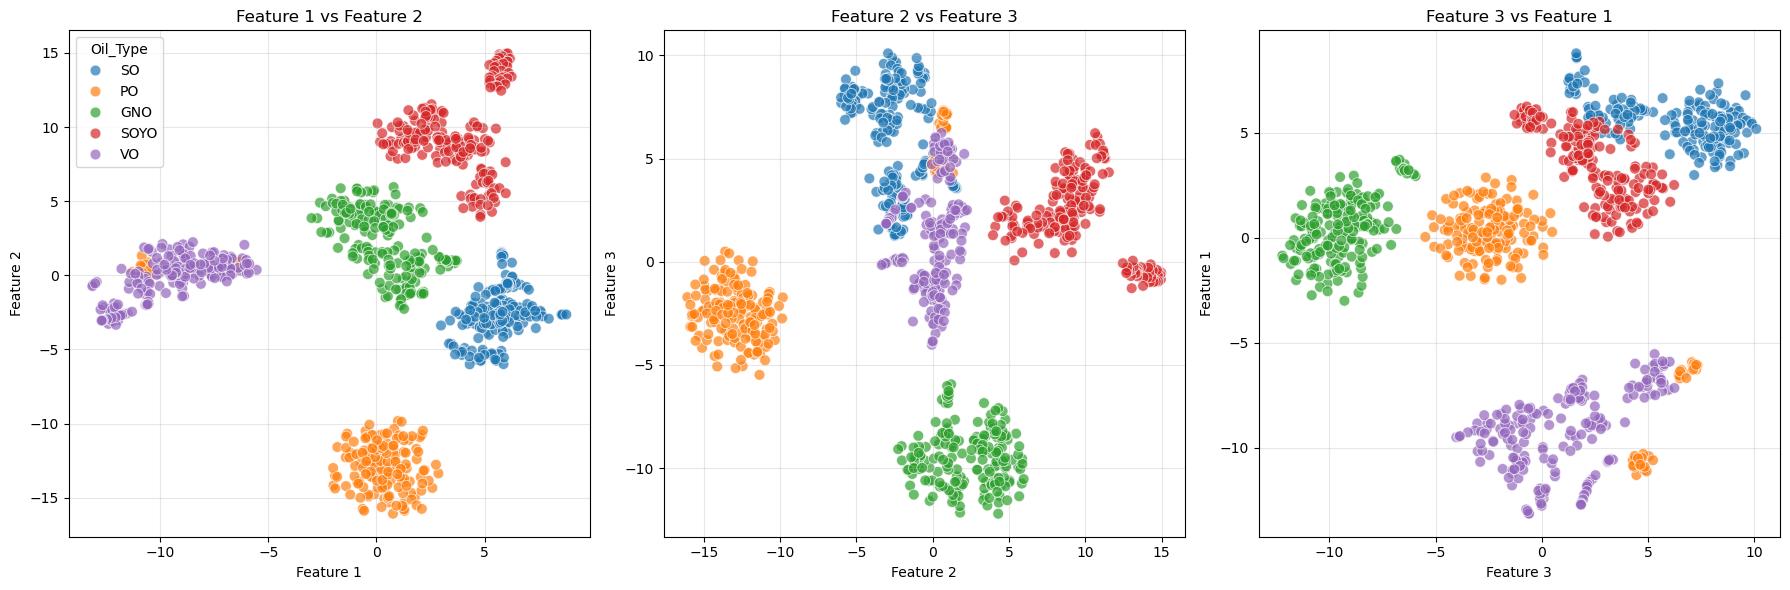

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Feature 1 vs Feature 2
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 1",
    y="Feature 2",
    hue="Oil_Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[0]
)

axes[0].set_title("Feature 1 vs Feature 2")
axes[0].grid(alpha=0.3)

# Feature 2 vs Feature 3
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 2",
    y="Feature 3",
    hue="Oil_Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[1]
)

axes[1].set_title("Feature 2 vs Feature 3")
axes[1].grid(alpha=0.3)

# Feature 3 vs Feature 1
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 3",
    y="Feature 1",
    hue="Oil_Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[2]
)

axes[2].set_title("Feature 3 vs Feature 1")
axes[2].grid(alpha=0.3)

# Keep only one legend
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout()

plt.savefig(r"Images\K-Means Clusters\MinMaxScaler_tsne_3d_pairwise_projections_Oils.png",dpi=300,bbox_inches="tight")
plt.show()

In [26]:
palette = {
    "SO": "blue",
    "PO": "orange",
    "GNO": "green",
    "SOYO": "red",
    "VO": "purple"
}
# Add TRUE labels to 3D t-SNE
tsne_3d_data["True_Label"] = y.values

fig = px.scatter_3d(
    tsne_3d_data,
    x="Feature 1",
    y="Feature 2",
    z="Feature 3",
    color="True_Label",
    color_discrete_map=palette,
    title="t-SNE 3D (True Labels)"
)

fig.write_image(r"Images\K-Means Clusters\MinMaxScaler_tsne_3d_oils_plot.jpg")
fig.show()

In [27]:
k_means_df = subset_scaled_df.copy()

### Elbow (WCSS) across k=2..10: Fit K‑means and record inertia to eyeball elbow.

In [28]:
clusters = range(2, 11)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_


    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)

Number of Clusters: 2 	wcss: 26691.879825570435
Number of Clusters: 3 	wcss: 18077.2334661253
Number of Clusters: 4 	wcss: 17569.740466945375
Number of Clusters: 5 	wcss: 13070.605670306215
Number of Clusters: 6 	wcss: 11083.484122973292
Number of Clusters: 7 	wcss: 10264.873657611828
Number of Clusters: 8 	wcss: 10105.931975861542
Number of Clusters: 9 	wcss: 9703.398023864207
Number of Clusters: 10 	wcss: 9441.131911924746


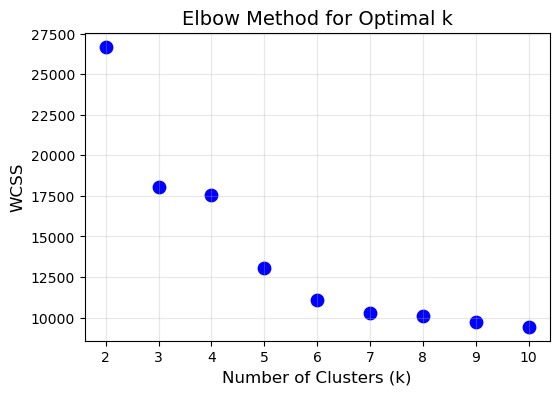

In [29]:
plt.figure(figsize=(6,4))

plt.scatter(
    clusters,
    WCSS,
    s=80,           # marker size
    color='blue',
    marker='o'
)

plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.title("Elbow Method for Optimal k", fontsize=14)

plt.xticks(clusters)
plt.grid(alpha=0.3)
plt.savefig(r"Images\K-Means Clusters\MinMaxScaler_elbow_plot_oils.jpg",dpi=300,bbox_inches='tight')
plt.show()

### Compute silhouette scores for k=2..9 and plot them to complement elbow.

In [30]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=RS)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.6032184079376978)
For n_clusters = 3, the silhouette score is 0.4249314423593349)
For n_clusters = 4, the silhouette score is 0.29555688325819346)
For n_clusters = 5, the silhouette score is 0.32474402883193676)
For n_clusters = 6, the silhouette score is 0.3234857746942098)
For n_clusters = 7, the silhouette score is 0.31775606889297114)
For n_clusters = 8, the silhouette score is 0.29724690574947726)
For n_clusters = 9, the silhouette score is 0.2882405940359881)


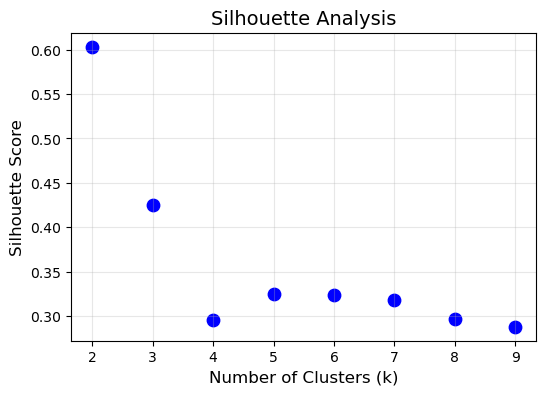

In [31]:
plt.figure(figsize=(6,4))

plt.scatter(
    cluster_list,
    sil_score,
    s=80,
    color='blue',
    marker='o'
)

plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Analysis", fontsize=14)

plt.xticks(cluster_list)
plt.grid(alpha=0.3)

plt.savefig(r"Images\K-Means Clusters\MinMaxScaler_silhouette_oils_plot.jpg", dpi=300, bbox_inches='tight')

plt.show()

In [32]:
n_clusters = list(range(2, 10))
sil_oil = []

for n_cluster in n_clusters:
    clusterer = KMeans(n_clusters=n_cluster, random_state=RS)
    preds = clusterer.fit_predict(subset_scaled_df)
    score = silhouette_score(k_means_df, preds)
    sil_oil.append(score)

    print("For n_clusters = {}, the silhouette score is {}".format(n_cluster, score))

print("n_clusters:", n_clusters)
print("sil_oil:", sil_oil)

For n_clusters = 2, the silhouette score is 0.6032184079376978
For n_clusters = 3, the silhouette score is 0.4249314423593349
For n_clusters = 4, the silhouette score is 0.29555688325819346
For n_clusters = 5, the silhouette score is 0.32474402883193676
For n_clusters = 6, the silhouette score is 0.3234857746942098
For n_clusters = 7, the silhouette score is 0.31775606889297114
For n_clusters = 8, the silhouette score is 0.29724690574947726
For n_clusters = 9, the silhouette score is 0.2882405940359881
n_clusters: [2, 3, 4, 5, 6, 7, 8, 9]
sil_oil: [0.6032184079376978, 0.4249314423593349, 0.29555688325819346, 0.32474402883193676, 0.3234857746942098, 0.31775606889297114, 0.29724690574947726, 0.2882405940359881]


In [33]:
# Ensure column names are strings (required by sklearn sometimes)
k_means_df.columns = k_means_df.columns.astype(str)
# -------- K-MEANS MODEL --------
kmeans = KMeans(n_clusters=5, random_state=RS)
kmeans.fit(k_means_df)

# -------- CREATE COPIES --------
df1 = df.copy()   # original (unscaled)

In [34]:
# -------- ASSIGN CLUSTERS --------
# scaled high-dimensional data (k_means_df) to which we are adding a new column and assigning labels. 
#Each data point is tagged with its cluster now
k_means_df["K_means_segments"] = kmeans.labels_    
df1["K_means_segments"] = kmeans.labels_             # original unscaled data to which same cluster labels are added
tsne_2d_data["K_means_segments"] = kmeans.labels_    # t-SNE 2D data tagged with cluster labels
tsne_3d_data["K_means_segments"] = kmeans.labels_    # t-SNE 3D data tagged with cluster labels

In [35]:
# Map cluster number -> oil name
cluster_map = pd.crosstab(y, kmeans.labels_).idxmax()

# Convert to dictionary
mapping = cluster_map.to_dict()

# Create cluster labels
tsne_2d_data["Cluster_Label"] = pd.Series(kmeans.labels_).map(mapping)

print(tsne_2d_data["Cluster_Label"].value_counts())

Cluster_Label
GNO    400
VO     240
SO     200
PO     160
Name: count, dtype: int64


### From the above, K-Means clusters are not perfectly aligned with the true oil labels. The overlap between PO and VO can be observed here.

In [36]:
# 1. Cross-tabulation (MOST IMPORTANT)
cluster_vs_label = pd.crosstab(y, kmeans.labels_, margins=True)
print("\n=== Cluster vs True Label Comparison ===")
print(cluster_vs_label)
# 2. Dominant cluster per oil type (optional but very important)
dominant_cluster = cluster_vs_label.drop("All", axis=1).idxmax(axis=1)
print("\n=== Dominant Cluster for Each Oil Type ===")
print(dominant_cluster)
# 3. (OPTIONAL) Add TRUE labels to t-SNE for visual validation
tsne_2d_data["True_Label"] = y.values


=== Cluster vs True Label Comparison ===
col_0    0    1    2    3    4   All
Oil                                 
GNO    200    0    0    0    0   200
PO       0   40  160    0    0   200
SO       0    0    0    0  200   200
SOYO   200    0    0    0    0   200
VO       0   96    0  104    0   200
All    400  136  160  104  200  1000

=== Dominant Cluster for Each Oil Type ===
Oil
GNO     0
PO      2
SO      4
SOYO    0
VO      3
All     0
dtype: object


In [37]:
print(tsne_2d_data.columns)

Index(['Feature 1', 'Feature 2', 'Oil_Type', 'K_means_segments',
       'Cluster_Label', 'True_Label'],
      dtype='object')


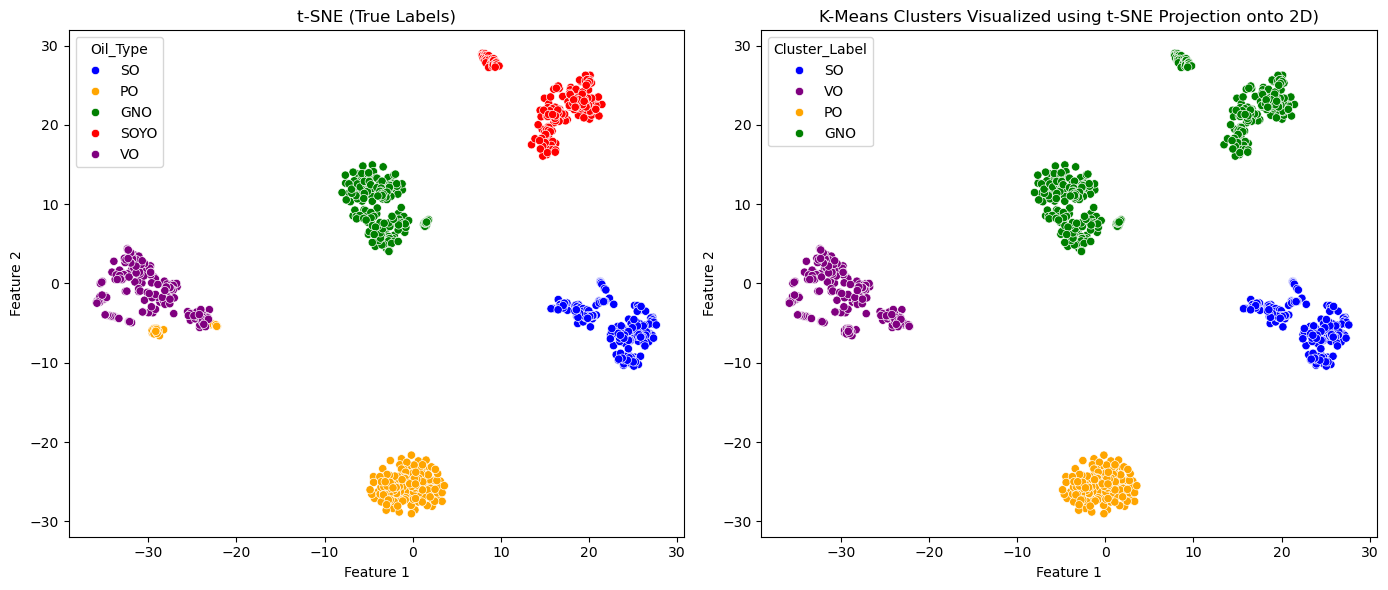

In [38]:
# Plot TRUE label vs CLUSTER comparison side-by-side
plt.figure(figsize=(14,6))
# TRUE LABELS
plt.subplot(1,2,1)
sns.scatterplot(
    data=tsne_2d_data,
    x="Feature 1",
    y="Feature 2",
    #hue="True_Label",
    hue="Oil_Type",
    palette=palette
    #palette="tab10"
)
plt.title("t-SNE (True Labels)")
# CLUSTERS
plt.subplot(1,2,2)
sns.scatterplot(
    data=tsne_2d_data,
    x="Feature 1",
    y="Feature 2",
    #hue="K_means_segments",
    hue="Cluster_Label",
    #palette="tab10"
    palette=palette
)
plt.title("K-Means Clusters Visualized using t-SNE Projection onto 2D)")
plt.tight_layout()
plt.savefig(r"Images\K-Means Clusters\MinMaxScaler_kmeans_tsne_clusters_oils.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()